# Sensitivity Analysis — Moment-Parameter Jacobian

**Goal:** learn which parameters actually move which moments.

**Method:**
1. Load the solver from `../solver/`, solve at the baseline calibration.
2. Perturb each of the 26 free parameters by ±10 %.
3. Compute a central-difference numerical Jacobian (elasticity matrix).
4. Flag weakly-identified parameters (max |elasticity| < 0.1).

Uses a coarser grid (`Nx = Np = 60`) and relaxed tolerances for speed.
The full loop (26 params × 2 directions = 52 solves) takes ~2–5 min
depending on thread count.

## 1 · Packages and solver files

In [1]:
using LinearAlgebra, SparseArrays, Statistics, Random
using Distributions, FastGaussQuadrature, Interpolations
using Parameters, Printf
using Base.Threads

Random.seed!(42)

# Load every solver file from ../solver/ — notebook lives in notebooks/
const SOLVER_DIR = joinpath(@__DIR__, "..", "solver")

include(joinpath(SOLVER_DIR, "grids.jl"))
include(joinpath(SOLVER_DIR, "params.jl"))
include(joinpath(SOLVER_DIR, "unskilled.jl"))
include(joinpath(SOLVER_DIR, "skilled.jl"))
include(joinpath(SOLVER_DIR, "solver.jl"))
include(joinpath(SOLVER_DIR, "equilibrium.jl"))

println("Solver loaded  |  threads: ", Threads.nthreads())

Solver loaded  |  threads: 10


## 2 · Solver settings

In [2]:
# Tight settings for the single baseline solve (Nx=200).
const SIM_BASELINE = SimParams(
    tol_inner=1e-8, tol_outer_U=1e-6, tol_outer_S=1e-7, tol_global=1e-3,
    maxit_inner=500, maxit_outer=300, maxit_global=200, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.30, damp_pstar_S=1.00,
    verbose=2, verbose_stride=30,
)

# Relaxed settings for the 52 sensitivity solves (fast)
const SIM_FAST = SimParams(
    tol_inner=1e-6, tol_outer_U=1e-4, tol_outer_S=1e-4, tol_global=1e-2,
    maxit_inner=500, maxit_outer=300, maxit_global=100, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.30, damp_pstar_S=0.95,
    verbose=1, verbose_stride=5,
)

# Coarser grid for sensitivity solves
const SENS_NX = 60 ; const SENS_NP = 60
println("Settings ready.")

Settings ready.


## 3 · Default parameter dictionary

In [3]:
# Flat dictionary: ASCII keys map unambiguously to struct fields.
# Struct-qualified names (unsk_* / skl_*) disambiguate the two markets.
const DEFAULT_PARAMS = Dict{Symbol,Float64}(
    # CommonParams
    :r       => 0.00417,
    :nu      => 0.03841,
    :phi     => 0.02222,
    :a_l     => 2.77289,
    :b_l     => 5.99306,
    :c       => 2.63910,
    # RegimeParams
    :PU      => 0.30158,
    :PS      => 1.11405,
    :bU      => 0.00000,
    :bT      => 0.14976,
    :bS      => 0.01326,
    :alpha_U => 0.64902,
    :a_Gam   => 1.51621,
    :b_Gam   => 4.97038,
    # UnskilledParams
    :unsk_mu  => 0.71488,
    :unsk_eta => 0.69515,
    :unsk_k   => 0.24711,
    :unsk_bet => 0.17956,
    :unsk_lam => 0.03932,
    # SkilledParams
    :skl_mu   => 0.81565,
    :skl_eta  => 0.53264,
    :skl_k    => 0.36195,
    :skl_bet  => 0.22479,
    :skl_xi   => 0.03311,
    :skl_lam  => 0.10260,
    :skl_sig  => 0.00429,
)

# Ordered list of param keys (for iteration) with human-readable labels
const PARAM_SPECS = [
    (:r,       "discount rate r"),
    (:nu,      "demographic exit ν"),
    (:phi,     "training completion φ"),
    (:a_l,     "worker type shape a_ℓ"),
    (:b_l,     "worker type shape b_ℓ"),
    (:c,       "training cost c"),
    (:PU,      "unskilled productivity PU"),
    (:PS,      "skilled productivity PS"),
    (:bU,      "unskilled UI flow bU"),
    (:bT,      "training flow bT"),
    (:bS,      "skilled UI flow bS"),
    (:alpha_U, "damage shock shape α_U"),
    (:a_Gam,   "skilled offer shape a_Γ"),
    (:b_Gam,   "skilled offer shape b_Γ"),
    (:unsk_mu,  "unskilled matching eff μ_U"),
    (:unsk_eta, "unskilled matching elas η_U"),
    (:unsk_k,   "unskilled vacancy cost k_U"),
    (:unsk_bet, "unskilled bargaining β_U"),
    (:unsk_lam, "unskilled damage rate λ_U"),
    (:skl_mu,   "skilled matching eff μ_S"),
    (:skl_eta,  "skilled matching elas η_S"),
    (:skl_k,    "skilled vacancy cost k_S"),
    (:skl_bet,  "skilled bargaining β_S"),
    (:skl_xi,   "skilled exog sep rate ξ_S"),
    (:skl_lam,  "skilled quality shock λ_S"),
    (:skl_sig,  "OJS flow cost σ"),
]

const PARAM_KEYS   = first.(PARAM_SPECS)
const PARAM_LABELS = last.(PARAM_SPECS)
println("Parameters defined: ", length(PARAM_KEYS), " free params")

Parameters defined: 26 free params


## 4 · Rebuild all param structs from a flat dictionary

In [4]:
"""
    build_params(d) -> (CommonParams, RegimeParams, UnskilledParams, SkilledParams)

Reconstructs all four parameter structs from the flat dict `d`.
"""
function build_params(d::Dict{Symbol,Float64})
    common = CommonParams(
        r   = d[:r],
        ν   = d[:nu],
        φ   = d[:phi],
        a_ℓ = d[:a_l],
        b_ℓ = d[:b_l],
        c   = d[:c],
    )
    regime = RegimeParams(
        PU  = d[:PU],
        PS  = d[:PS],
        bU  = d[:bU],
        bT  = d[:bT],
        bS  = d[:bS],
        α_U = d[:alpha_U],
        a_Γ = d[:a_Gam],
        b_Γ = d[:b_Gam],
    )
    unsk = UnskilledParams(
        μ = d[:unsk_mu],
        η = d[:unsk_eta],
        k  = d[:unsk_k],
        β = d[:unsk_bet],
        λ = d[:unsk_lam],
    )
    skl = SkilledParams(
        μ = d[:skl_mu],
        η = d[:skl_eta],
        k  = d[:skl_k],
        β = d[:skl_bet],
        ξ = d[:skl_xi],
        λ = d[:skl_lam],
        σ = d[:skl_sig],
    )
    return common, regime, unsk, skl
end
println("build_params defined.")

build_params defined.


## 5 · Moment computation

In [5]:
"""
    compute_moments(obj) -> NamedTuple

Compute 22 core moments (same order as the SMM objective) plus 6
notebook-only diagnostics from the equilibrium object `obj`.
"""
function compute_moments(obj)

    # ── Labour market stocks ──────────────────────────────────────────────
    ur_U           = obj.ur_U
    ur_S           = obj.ur_S
    skilled_share  = obj.agg_mS  / max(obj.total_pop, 1e-14)
    training_share = obj.agg_t   / max(obj.total_pop, 1e-14)

    wmid_tmp   = obj.wmid
    dens_U_tmp = obj.dens_U
    dens_S_tmp = obj.dens_S
    bw_tmp     = wmid_tmp[2] - wmid_tmp[1]

    _mean_U_tmp = sum(wmid_tmp .* dens_U_tmp) * bw_tmp
    _mean_S_tmp = sum(wmid_tmp .* dens_S_tmp) * bw_tmp

    emp_var_U  = sum((wmid_tmp .- _mean_U_tmp).^2 .* dens_U_tmp) * bw_tmp
    emp_cm3_U  = sum((wmid_tmp .- _mean_U_tmp).^3 .* dens_U_tmp) * bw_tmp
    emp_var_S  = sum((wmid_tmp .- _mean_S_tmp).^2 .* dens_S_tmp) * bw_tmp
    emp_cm3_S  = sum((wmid_tmp .- _mean_S_tmp).^3 .* dens_S_tmp) * bw_tmp

    # ── Transition rates ──────────────────────────────────────────────────
    jfr_U         = obj.f_U
    jfr_S         = obj.f_S
    sep_rate_U    = obj.sep_rate_U
    sep_rate_S    = obj.sep_rate_S
    ee_rate_S     = obj.ee_rate_S

    # ── Wages ─────────────────────────────────────────────────────────────
    wmid   = obj.wmid
    dens_U = obj.dens_U
    dens_S = obj.dens_S
    bw     = wmid[2] - wmid[1]

    mean_wage_U = sum(wmid .* dens_U) * bw
    mean_wage_S = sum(wmid .* dens_S) * bw

    function _percentile(wmid, dens, bw, target)
        cum = 0.0
        for (w, d) in zip(wmid, dens)
            cum += d * bw
            cum >= target && return w
        end
        return wmid[end]
    end

    p25_wage_U = _percentile(wmid, dens_U, bw, 0.25)
    p25_wage_S = _percentile(wmid, dens_S, bw, 0.25)
    p50_wage_U = _percentile(wmid, dens_U, bw, 0.50)
    p50_wage_S = _percentile(wmid, dens_S, bw, 0.50)

    mean_log_wage_U = sum(log.(max.(wmid, 1e-14)) .* dens_U) * bw
    mean_log_wage_S = sum(log.(max.(wmid, 1e-14)) .* dens_S) * bw
    wage_premium    = mean_log_wage_S - mean_log_wage_U

    # ── Tightness ─────────────────────────────────────────────────────────
    theta_U = obj.thetaU
    theta_S = obj.thetaS

    # ── Notebook-only diagnostics ─────────────────────────────────────────
    ur_total       = obj.ur_total
    training_rate  = (obj.agg_t > 0 && obj.agg_uU > 0) ?
        obj.agg_t / max(obj.agg_uU, 1e-14) : 0.0

    var_U     = sum((wmid .- mean_wage_U).^2 .* dens_U) * bw
    var_S     = sum((wmid .- mean_wage_S).^2 .* dens_S) * bw
    wage_sd_U = sqrt(max(var_U, 0.0))
    wage_sd_S = sqrt(max(var_S, 0.0))

    p10_wage_U = _percentile(wmid, dens_U, bw, 0.10)
    p10_wage_S = _percentile(wmid, dens_S, bw, 0.10)

    return (
        # ── Core 22 moments ───────────────────────────────────────────────
        ur_U          = ur_U,
        ur_S          = ur_S,
        skilled_share = skilled_share,
        training_share = training_share,
        emp_var_U     = emp_var_U,
        emp_cm3_U     = emp_cm3_U,
        emp_var_S     = emp_var_S,
        emp_cm3_S     = emp_cm3_S,
        jfr_U         = jfr_U,
        sep_rate_U    = sep_rate_U,
        jfr_S         = jfr_S,
        sep_rate_S    = sep_rate_S,
        ee_rate_S     = ee_rate_S,
        mean_wage_U   = mean_wage_U,
        mean_wage_S   = mean_wage_S,
        p25_wage_U    = p25_wage_U,
        p25_wage_S    = p25_wage_S,
        p50_wage_U    = p50_wage_U,
        p50_wage_S    = p50_wage_S,
        wage_premium  = wage_premium,
        theta_U       = theta_U,
        theta_S       = theta_S,
        # ── Notebook-only diagnostics ─────────────────────────────────────
        ur_total       = ur_total,
        training_rate  = training_rate,
        wage_sd_U      = wage_sd_U,
        wage_sd_S      = wage_sd_S,
        p10_wage_U     = p10_wage_U,
        p10_wage_S     = p10_wage_S,
    )
end
println("compute_moments defined  (22 core + 6 diagnostic moments).")

compute_moments defined  (22 core + 6 diagnostic moments).


## 6 · `run_at_params` helper

In [7]:
"""
    run_at_params(d; sim, Nx, Np_U, Np_S) -> (moments, converged::Bool)

Build structs from dict `d`, solve via `solve_model()`, return moments
and a convergence flag.
"""
function run_at_params(d;
                        sim  = SIM_FAST,
                        Nx   = SENS_NX,
                        Np_U = SENS_NP,
                        Np_S = SENS_NP)
    cp, rp, up, sp = build_params(d)
    model, result  = solve_model(cp, rp, up, sp, sim; Nx=Nx, Np_U=Np_U, Np_S=Np_S)
    result.ok || @warn "Model did not fully converge"
    obj = compute_equilibrium_objects(model)
    m   = compute_moments(obj)
    return m, result.ok
end
println("run_at_params defined.")

run_at_params defined.


## 7 · Baseline solve at default parameters

In [8]:
println("Solving baseline (full resolution, tight tolerances)...")
@time global m_base, ok_base = run_at_params(DEFAULT_PARAMS;
                                               sim  = SIM_BASELINE,
                                               Nx   = 200,
                                               Np_U = 200,
                                               Np_S = 200)
println("\nBaseline converged: ", ok_base)

Solving baseline (full resolution, tight tolerances)...
  [outer U it=1]  maxΔ=8.803e-01  (Δθ=5.155e-03  Δp*=7.664e-01  Δu=8.803e-01)  θ=0.9948
  [outer U]  converged it=15  d=2.132e-07  θ=1.1185
  [outer S it=1]  maxΔ=7.258e-01  (Δθ=7.258e-01  Δp*=8.952e-01  Δpoj=9.500e-01)  θ=0.2742
  [outer S]  converged it=13  d=3.361e-08  θ=0.4216
[global it=1]  maxΔ=3.658e+00  (ΔUS=3.658e+00  ΔmS=5.775e-01)  θU=1.1185  θS=0.4216
  [outer U it=1]  maxΔ=1.459e-01  (Δθ=2.865e-02  Δp*=2.564e-02  Δu=1.459e-01)  θ=1.0898
  [outer U it=30]  maxΔ=1.378e-01  (Δθ=7.844e-04  Δp*=3.593e-04  Δu=1.378e-01)  θ=1.0837
  [outer U it=60]  maxΔ=1.378e-01  (Δθ=7.844e-04  Δp*=3.592e-04  Δu=1.378e-01)  θ=1.0837
  [outer U it=90]  maxΔ=1.378e-01  (Δθ=7.844e-04  Δp*=3.592e-04  Δu=1.378e-01)  θ=1.0837
  [outer U it=120]  maxΔ=1.378e-01  (Δθ=7.844e-04  Δp*=3.592e-04  Δu=1.378e-01)  θ=1.0837
  [outer U it=150]  maxΔ=1.378e-01  (Δθ=7.844e-04  Δp*=3.592e-04  Δu=1.378e-01)  θ=1.0837
  [outer U it=180]  maxΔ=1.378e-01  (Δθ=7.8

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


## 8 · Baseline moments

In [9]:
println()
@printf("%-20s  %10s\n", "Moment", "Baseline")
println("-" ^ 34)
for (k, v) in pairs(m_base)
    @printf("%-20s  %10.5f\n", string(k), v)
end


Moment                  Baseline
----------------------------------
ur_U                     0.05836
ur_S                     0.11574
skilled_share            0.14916
training_share           0.25784
emp_var_U                0.00136
emp_cm3_U                0.00002
emp_var_S                0.00047
emp_cm3_S                0.00000
jfr_U                    0.73294
sep_rate_U               0.02857
jfr_S                    0.54772
sep_rate_S               0.03311
ee_rate_S                0.02816
mean_wage_U              0.06260
mean_wage_S              0.06526
p25_wage_U               0.03061
p25_wage_S               0.05160
p50_wage_U               0.05334
p50_wage_S               0.06384
wage_premium             0.18056
theta_U                  1.08528
theta_S                  0.42653
ur_total                 0.06692
training_rate            5.19271
wage_sd_U                0.03686
wage_sd_S                0.02174
p10_wage_U               0.02012
p10_wage_S               0.04285


## 9 · Sensitivity loop

Perturbation rule:
- **Relative:** $v_0 \pm 10\%$ when $|v_0| > 10^{-8}$
- **Absolute:** $v_0 \pm 0.05$ for zero-valued params
- Minus-side floored at $10^{-8}$

In [10]:
const DELTA     = 0.10    # relative step size (10%)
const DELTA_ABS = 0.05    # absolute step for zero-valued params

moment_keys = propertynames(m_base)
n_moments   = length(moment_keys)
n_params    = length(PARAM_KEYS)

# Pre-allocate result storage
moments_plus  = Vector{Any}(undef, n_params)
moments_minus = Vector{Any}(undef, n_params)
conv_plus     = falses(n_params)
conv_minus    = falses(n_params)
step_used     = zeros(n_params)

println("\nSensitivity loop: ", n_params, " params x 2 directions")
println("=" ^ 62)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = DEFAULT_PARAMS[pkey]
    step = abs(v0) > 1e-8 ? DELTA * abs(v0) : DELTA_ABS
    step_used[i] = step

    @printf("[%2d/%2d]  %-28s  v0=%7.4f  step=%6.4f", i, n_params, string(pkey), v0, step)

    d_plus        = copy(DEFAULT_PARAMS)
    d_plus[pkey]  = v0 + step
    mp, cp_ok     = run_at_params(d_plus)
    moments_plus[i]  = mp
    conv_plus[i]     = cp_ok

    d_minus       = copy(DEFAULT_PARAMS)
    d_minus[pkey] = max(v0 - step, 1e-8)
    mm, cm_ok     = run_at_params(d_minus)
    moments_minus[i] = mm
    conv_minus[i]    = cm_ok

    println("  ", (cp_ok && cm_ok) ? "ok" : "WARN")
end
println("\nSensitivity loop complete.")


Sensitivity loop: 26 params x 2 directions
[ 1/26]  r                             v0= 0.0042  step=0.0004[global it=1]  maxΔ=3.610e+00  (ΔUS=3.610e+00  ΔmS=5.775e-01)  θU=1.1157  θS=0.4203
[global it=5]  maxΔ=9.585e-03  (ΔUS=9.585e-03  ΔmS=9.402e-07)  θU=1.0695  θS=0.4366
[global]  converged it=6  d=9.936e-03
[global it=1]  maxΔ=3.702e+00  (ΔUS=3.702e+00  ΔmS=5.775e-01)  θU=1.1204  θS=0.4226
  [outer U]  maxit reached without convergence  θ=1.1188
  [outer U]  maxit reached without convergence  θ=1.1257
  [outer U]  maxit reached without convergence  θ=1.0988
[global it=5]  maxΔ=4.373e-04  (ΔUS=6.216e-05  ΔmS=4.373e-04)  θU=1.0988  θS=0.4217
[global]  converged it=5  d=4.373e-04
  WARN
[ 2/26]  nu                            v0= 0.0384  step=0.0038

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


[global it=1]  maxΔ=3.270e+00  (ΔUS=3.270e+00  ΔmS=5.359e-01)  θU=1.0964  θS=0.4109
[global it=5]  maxΔ=2.791e-02  (ΔUS=2.791e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=10]  maxΔ=2.744e-02  (ΔUS=2.744e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=15]  maxΔ=2.771e-02  (ΔUS=2.771e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=20]  maxΔ=2.178e-02  (ΔUS=2.178e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=25]  maxΔ=2.726e-02  (ΔUS=2.726e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=30]  maxΔ=2.771e-02  (ΔUS=2.771e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=35]  maxΔ=2.178e-02  (ΔUS=2.178e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=40]  maxΔ=2.726e-02  (ΔUS=2.726e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=45]  maxΔ=2.771e-02  (ΔUS=2.771e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=50]  maxΔ=2.178e-02  (ΔUS=2.178e-02  ΔmS=0.000e+00)  θU=1.0964  θS=0.4109
[global it=55]  maxΔ=2.726e-02  (ΔUS=2.726e-02  ΔmS=0.000e+00)  θU=

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


[global it=1]  maxΔ=4.120e+00  (ΔUS=4.120e+00  ΔmS=6.261e-01)  θU=1.1403  θS=0.4323
[global it=5]  maxΔ=2.126e-01  (ΔUS=3.535e-02  ΔmS=2.126e-01)  θU=1.3349  θS=0.2602
[global it=10]  maxΔ=2.819e-02  (ΔUS=2.819e-02  ΔmS=2.535e-05)  θU=1.3344  θS=0.2749
[global]  converged it=12  d=1.627e-03
  WARN
[ 3/26]  phi                           v0= 0.0222  step=0.0022[global it=1]  maxΔ=3.655e+00  (ΔUS=3.655e+00  ΔmS=6.213e-01)  θU=1.1181  θS=0.4214
[global it=5]  maxΔ=3.166e-02  (ΔUS=3.166e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=10]  maxΔ=3.074e-02  (ΔUS=3.074e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=15]  maxΔ=3.019e-02  (ΔUS=3.019e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=20]  maxΔ=2.641e-02  (ΔUS=2.641e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=25]  maxΔ=3.069e-02  (ΔUS=3.069e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=30]  maxΔ=3.019e-02  (ΔUS=3.019e-02  ΔmS=0.000e+00)  θU=1.1181  θS=0.4214
[global it=35]  maxΔ=2.641e-02  (ΔUS=2.641e-02

...

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


[global it=1]  maxΔ=3.655e+00  (ΔUS=3.655e+00  ΔmS=5.775e-01)  θU=1.1181  θS=0.4212
[global it=5]  maxΔ=1.009e-02  (ΔUS=1.009e-02  ΔmS=9.395e-07)  θU=1.0687  θS=0.4376
[global it=10]  maxΔ=2.572e-02  (ΔUS=2.572e-02  ΔmS=8.495e-08)  θU=1.0682  θS=0.4376
[global it=15]  maxΔ=3.187e-02  (ΔUS=3.187e-02  ΔmS=5.004e-11)  θU=1.0682  θS=0.4376
[global it=20]  maxΔ=3.096e-02  (ΔUS=3.096e-02  ΔmS=2.022e-10)  θU=1.0682  θS=0.4376
[global it=25]  maxΔ=2.745e-02  (ΔUS=2.745e-02  ΔmS=7.187e-11)  θU=1.0682  θS=0.4376
[global it=30]  maxΔ=3.191e-02  (ΔUS=3.191e-02  ΔmS=1.299e-10)  θU=1.0682  θS=0.4376
[global it=35]  maxΔ=3.096e-02  (ΔUS=3.096e-02  ΔmS=2.018e-10)  θU=1.0682  θS=0.4376
[global it=40]  maxΔ=2.745e-02  (ΔUS=2.745e-02  ΔmS=7.187e-11)  θU=1.0682  θS=0.4376
[global it=45]  maxΔ=3.191e-02  (ΔUS=3.191e-02  ΔmS=1.299e-10)  θU=1.0682  θS=0.4376
[global it=50]  maxΔ=3.096e-02  (ΔUS=3.096e-02  ΔmS=2.018e-10)  θU=1.0682  θS=0.4376
[global it=55]  maxΔ=2.745e-02  (ΔUS=2.745e-02  ΔmS=7.187e-11)  θU=

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


[global it=1]  maxΔ=3.656e+00  (ΔUS=3.656e+00  ΔmS=5.775e-01)  θU=1.1181  θS=0.4216
[global it=5]  maxΔ=1.382e-02  (ΔUS=1.382e-02  ΔmS=1.079e-06)  θU=1.0685  θS=0.4376
[global it=10]  maxΔ=3.017e-02  (ΔUS=3.017e-02  ΔmS=1.134e-08)  θU=1.0681  θS=0.4376
[global it=15]  maxΔ=2.895e-02  (ΔUS=2.895e-02  ΔmS=1.950e-11)  θU=1.0681  θS=0.4376
[global it=20]  maxΔ=2.619e-02  (ΔUS=2.619e-02  ΔmS=2.248e-11)  θU=1.0681  θS=0.4376
[global it=25]  maxΔ=3.077e-02  (ΔUS=3.077e-02  ΔmS=7.414e-11)  θU=1.0681  θS=0.4376
[global it=30]  maxΔ=2.895e-02  (ΔUS=2.895e-02  ΔmS=9.652e-11)  θU=1.0681  θS=0.4376
[global it=35]  maxΔ=2.620e-02  (ΔUS=2.620e-02  ΔmS=2.230e-11)  θU=1.0681  θS=0.4376
[global it=40]  maxΔ=3.077e-02  (ΔUS=3.077e-02  ΔmS=7.415e-11)  θU=1.0681  θS=0.4376
[global it=45]  maxΔ=2.895e-02  (ΔUS=2.895e-02  ΔmS=9.657e-11)  θU=1.0681  θS=0.4376
[global it=50]  maxΔ=2.620e-02  (ΔUS=2.620e-02  ΔmS=2.230e-11)  θU=1.0681  θS=0.4376
[global it=55]  maxΔ=3.077e-02  (ΔUS=3.077e-02  ΔmS=7.408e-11)  θU=

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:14


## 10 · Build elasticity matrix

In [11]:
# Central-difference elasticity:
#   e_{j,i} = [(m_j(v+) - m_j(v-)) / (2 * step_i)] * (v_i / m_j_base)
# For zero-valued params: semi-elasticity (drop the v_i / m_j_base factor).
# For near-zero moments: fall back to absolute change.

E = zeros(n_moments, n_params)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = DEFAULT_PARAMS[pkey]
    step = step_used[i]

    for (j, mkey) in enumerate(moment_keys)
        m_plus_j  = getfield(moments_plus[i],  mkey)
        m_minus_j = getfield(moments_minus[i], mkey)
        m_base_j  = getfield(m_base, mkey)

        dm = (m_plus_j - m_minus_j) / (2.0 * step)

        if abs(m_base_j) > 1e-6
            scale    = abs(v0) > 1e-8 ? v0 / m_base_j : 1.0 / m_base_j
            E[j, i]  = dm * scale
        else
            E[j, i]  = dm
        end
    end
end

println("Jacobian computed: ", n_moments, " x ", n_params)

Jacobian computed: 28 x 26


## 11 · Full elasticity table

`*` marks cells where $|\text{elasticity}| \ge 0.1$.

In [12]:
# Short param abbreviations for the column header
p_abbr = [
    "r", "nu", "phi", "a_l", "b_l", "c",
    "PU", "PS", "bU", "bT", "bS", "aU", "aG", "bG",
    "mu_U", "et_U", "k_U", "be_U", "la_U",
    "mu_S", "et_S", "k_S", "be_S", "xi_S", "la_S", "si_S",
]

COL = 7   # column width

# header
print(rpad("Moment", 16))
for ab in p_abbr ; print(lpad(ab, COL)) ; end
println()
println("-" ^ (16 + COL * n_params))

# rows
for (j, mn) in enumerate(moment_keys)
    print(rpad(string(mn), 16))
    for i in 1:n_params
        e = E[j, i]
        @printf("%s%6.2f", abs(e) >= 0.1 ? "*" : " ", e)
    end
    println()
end
println()
println("* = |elast| >= 0.1")

Moment                r     nu    phi    a_l    b_l      c     PU     PS     bU     bT     bS     aU     aG     bG   mu_U   et_U    k_U   be_U   la_U   mu_S   et_S    k_S   be_S   xi_S   la_S   si_S
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ur_U            * -0.11*  2.99*  2.90*  0.79* -0.69*  3.32*  3.21* -3.16* 40.60* -3.88* -0.34*  0.37* -2.91*  3.11*  2.33* -0.10* -0.86*  2.63* -1.47* -1.80* -0.63*  0.47* -0.47*  0.47*  0.48  -0.00
ur_S              -0.07* -5.72* -5.41  -0.02  -0.02* -6.43* -5.04*  4.69* -9.94*  5.68*  0.11   0.06*  4.64* -4.67* -4.90  -0.08* -0.21*  0.25* -0.17* -1.30* -0.67*  0.57*  0.37*  0.56*  0.12  -0.00
skilled_share   *  0.33* -5.55* -5.86* -2.39*  2.20* -7.10* -8.26*  7.31* -9.83*  8.78*  0.75* -1.07*  6.89* -7.23* -7.59*  0.34*  2.58* -5.20*  4.10*  4.00*  1.40* -1.03*  1.03* -1.03* -1.02  -0.00
train

## 12 · Identification flags — max |elasticity| per parameter

A parameter is **weakly identified** if no moment has $|\text{elasticity}| \ge 0.1$.

In [13]:
println()
@printf("%-32s  %9s  %-18s  %s\n", "Parameter", "Max|elas|", "Best moment", "Flag")
println("-" ^ 76)

for (i, pkey) in enumerate(PARAM_KEYS)
    col      = abs.(E[:, i])
    max_abs  = maximum(col)
    best_j   = argmax(col)
    best_mom = string(moment_keys[best_j])
    flag     = max_abs < 0.1 ? ">>> WEAKLY IDENTIFIED" : ""
    lab      = PARAM_LABELS[i]
    @printf("%-32s  %9.4f  %-18s  %s\n", lab, max_abs, best_mom, flag)
end

println()
println("Weakly identified: no moment has |elasticity| >= 0.1.")
println("Action: add a targeted moment or fix the parameter externally.")


Parameter                         Max|elas|  Best moment         Flag
----------------------------------------------------------------------------
discount rate r                      1.6396  wage_premium        
demographic exit ν                  91.6934  wage_premium        
training completion φ               81.3155  wage_premium        
worker type shape a_ℓ               10.0045  wage_premium        
worker type shape b_ℓ                8.7639  wage_premium        
training cost c                     93.4741  wage_premium        
unskilled productivity PU           64.6247  wage_premium        
skilled productivity PS             67.7322  wage_premium        
unskilled UI flow bU               124.0577  wage_premium        
training flow bT                    87.4552  wage_premium        
skilled UI flow bS                   1.2039  training_rate       
damage shock shape α_U               1.6623  training_rate       
skilled offer shape a_Γ             67.8282  wage_premium   

## 13 · Most responsive parameter per moment

In [14]:
println()
@printf("%-20s  %9s  %-32s\n", "Moment", "Max|elas|", "Most responsive param")
println("-" ^ 65)

for (j, mn) in enumerate(moment_keys)
    row     = abs.(E[j, :])
    max_abs = maximum(row)
    best_p  = PARAM_LABELS[argmax(row)]
    @printf("%-20s  %9.4f  %-32s\n", string(mn), max_abs, best_p)
end


Moment                Max|elas|  Most responsive param           
-----------------------------------------------------------------
ur_U                    40.5954  unskilled UI flow bU            
ur_S                     9.9409  unskilled UI flow bU            
skilled_share            9.8292  unskilled UI flow bU            
training_share           9.8292  unskilled UI flow bU            
emp_var_U                6.9504  unskilled UI flow bU            
emp_cm3_U                8.9638  unskilled UI flow bU            
emp_var_S               11.3533  skilled productivity PS         
emp_cm3_S                0.0011  unskilled damage rate λ_U       
jfr_U                    4.6051  unskilled UI flow bU            
sep_rate_U               1.2789  unskilled UI flow bU            
jfr_S                    1.4576  skilled matching eff μ_S        
sep_rate_S              10.0019  unskilled UI flow bU            
ee_rate_S                9.6478  unskilled UI flow bU            
mean_wage

## 14 · Heatmap of the Jacobian

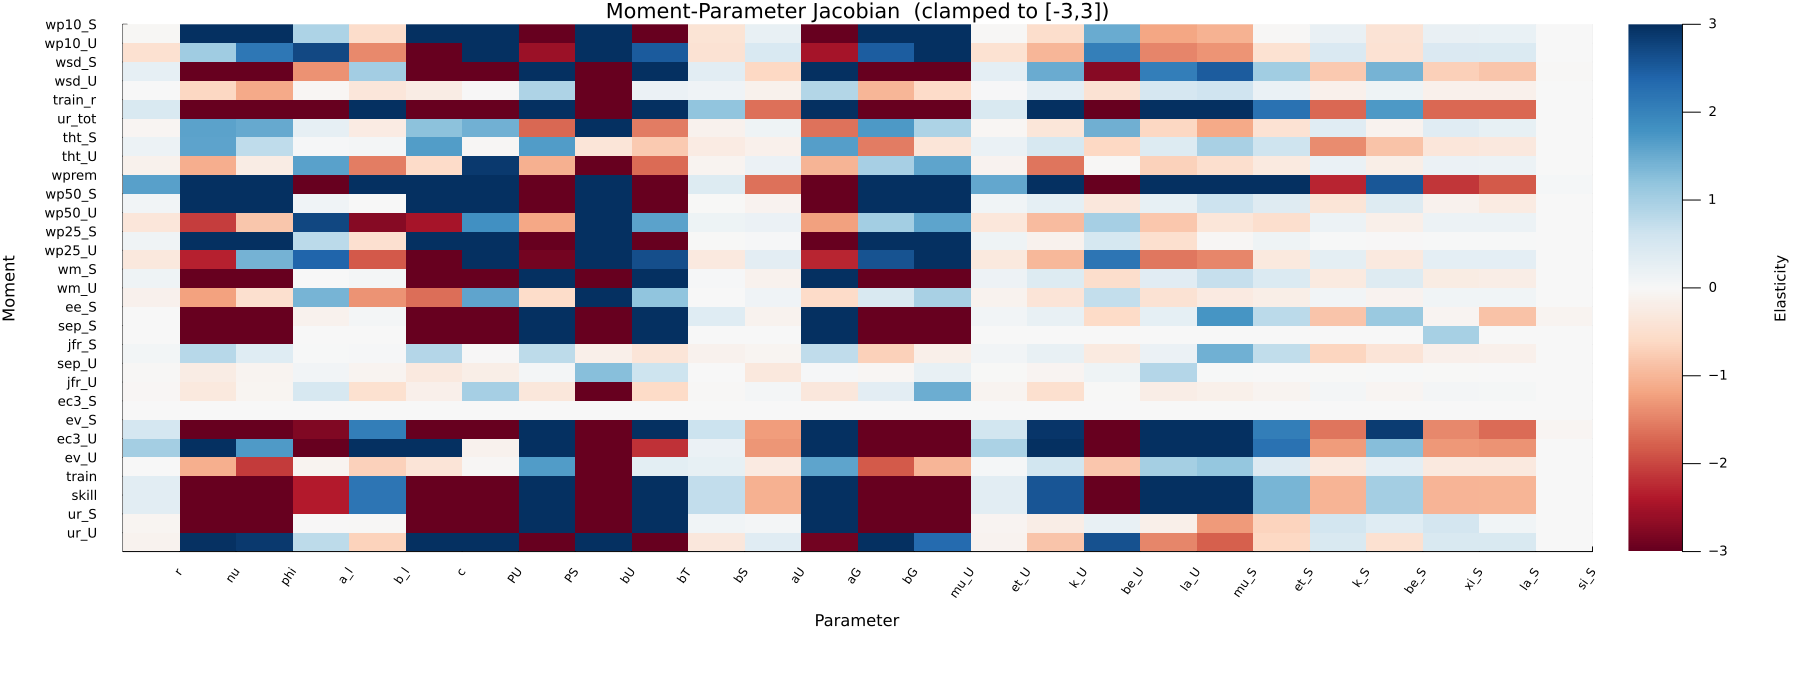

In [15]:
using Plots

# Short axis labels
m_short = [
    # ── Core 22 ───────────────────────────────────────────────────────
    "ur_U","ur_S","skill","train",
    "ev_U","ec3_U","ev_S","ec3_S",
    "jfr_U","sep_U","jfr_S","sep_S","ee_S",
    "wm_U","wm_S",
    "wp25_U","wp25_S","wp50_U","wp50_S",
    "wprem",
    "tht_U","tht_S",
    # ── Notebook-only diagnostics ─────────────────────────────────────
    "ur_tot","train_r",
    "wsd_U","wsd_S",
    "wp10_U","wp10_S",
]

E_clamp = clamp.(E, -3.0, 3.0)

hm = heatmap(
    p_abbr, m_short, E_clamp;
    color           = :RdBu,
    clim            = (-3, 3),
    title           = "Moment-Parameter Jacobian  (clamped to [-3,3])",
    xlabel          = "Parameter",
    ylabel          = "Moment",
    xrotation       = 55,
    xticks          = (1:length(p_abbr), p_abbr),
    xtickfontsize   = 8,
    yticks          = (1:length(m_short), m_short),
    ytickfontsize   = 9,
    size            = (1800, 680),
    left_margin     = 8Plots.mm,
    bottom_margin   = 22Plots.mm,
    colorbar_title  = "Elasticity",
)

display(hm)

## 15 · Top-3 most responsive moments per parameter

Use these pairings to assign non-zero weights in `default_targets()`.

In [16]:
println()
@printf("%-32s  %-18s  %-18s  %-18s\n", "Parameter", "1st moment", "2nd moment", "3rd moment")
println("-" ^ 90)

for (i, _) in enumerate(PARAM_KEYS)
    col   = abs.(E[:, i])
    order = sortperm(col; rev = true)
    top3  = [string(moment_keys[order[k]]) for k in 1:3]
    lab   = PARAM_LABELS[i]
    @printf("%-32s  %-18s  %-18s  %-18s\n", lab, top3...)
end

println()
println("Next: use these pairings to assign non-zero weights in default_targets().")


Parameter                         1st moment          2nd moment          3rd moment        
------------------------------------------------------------------------------------------
discount rate r                   wage_premium        emp_cm3_U           emp_var_S         
demographic exit ν                wage_premium        p10_wage_S          p25_wage_S        
training completion φ             wage_premium        p10_wage_S          p25_wage_S        
worker type shape a_ℓ             wage_premium        emp_cm3_U           training_rate     
worker type shape b_ℓ             wage_premium        emp_cm3_U           training_rate     
training cost c                   wage_premium        p10_wage_S          p25_wage_S        
unskilled productivity PU         wage_premium        p10_wage_S          p25_wage_S        
skilled productivity PS           wage_premium        p10_wage_S          p25_wage_S        
unskilled UI flow bU              wage_premium        ur_U             